#Case Study 2 – Analysis: rehab demand vs supply across Saudi regions, 2026

# 2.0 Setup: connecting Google Drive, loading pandas and defining the project folders

In [3]:
# 2.0 Setup: connecting Google Drive, loading pandas and defining the project folders

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import os

BASE    = '/content/drive/MyDrive/cs2-regional-demand'
CLEAN   = f'{BASE}/data/clean'
FINAL   = f'{BASE}/data/final'
TABLES  = f'{BASE}/outputs/tables'
FIGURES = f'{BASE}/outputs/figures'

print('Clean files available:', sorted(os.listdir(CLEAN)))

Mounted at /content/drive
Clean files available: ['context_clean.csv', 'national_2022.csv', 'pop_clean.csv', 'prev2016_clean.csv', 'region_lookup.csv', 'supply_clean.csv', 'typemix_clean.csv']


#2.1 Loading the clean data and joining it into one table per region

In [4]:
pop      = pd.read_csv(f'{CLEAN}/pop_clean.csv')
prev     = pd.read_csv(f'{CLEAN}/prev2016_clean.csv')
mix      = pd.read_csv(f'{CLEAN}/typemix_clean.csv')
supply   = pd.read_csv(f'{CLEAN}/supply_clean.csv')
context  = pd.read_csv(f'{CLEAN}/context_clean.csv')
national = pd.read_csv(f'{CLEAN}/national_2022.csv').set_index('key')['value']

# Saudi population with one column per year (used again in 2.2 and 2.3)
saudi_wide = pop.pivot(index='region', columns='year', values='saudi')

# Base table: 2022 population + 2016 rate + MOH supply + 2024 context
base = (saudi_wide[[2022]].rename(columns={2022: 'saudi_2022'}).reset_index()
        .merge(prev[['region', 'rate_pct']].rename(columns={'rate_pct': 'rate_2016_pct'}),
               on='region', how='left', validate='1:1')
        .merge(supply,  on='region', how='left', validate='1:1')
        .merge(context, on='region', how='left', validate='1:1'))

# Quality checks: 13 rows, nothing lost in the joins, only the five known gaps
print('Base table:', base.shape)
print('Empty cells per column:')
print(base.isna().sum()[base.isna().sum() > 0].to_string())
assert len(base) == 13, 'Expected 13 regions'
assert base.drop(columns='hospitals_all_2024').notna().all().all(), 'A join lost data'
assert base['hospitals_all_2024'].isna().sum() == 5, 'Expected the five hidden D5 labels only'
assert base['saudi_2022'].sum() == 18_792_262, 'Population total changed during the join'
assert base['moh_rehab_hospitals'].sum() == 235, 'Supply total changed during the join'

print(f"\nNational Saudi rate 2022: {national['rate_saudi_pct']}%")
print(base[['region', 'saudi_2022', 'rate_2016_pct', 'moh_rehab_hospitals',
            'prosthetics_orthotics', 'speech_therapy']].to_string(index=False))

Base table: (13, 13)
Empty cells per column:
hospitals_all_2024    5

National Saudi rate 2022: 5.9%
                  region  saudi_2022  rate_2016_pct  moh_rehab_hospitals  prosthetics_orthotics  speech_therapy
                Al Bahah      251288          1.304                    8                      0               0
                 Al Jawf      440264          3.786                   11                      1               3
Al Madinah Al Munawwarah     1352146          2.736                   11                      1               1
               Al Qaseem      926490          2.045                   13                      2               4
               Ar Riyadh     4439210          3.437                   40                      2               8
                   Aseer     1444688          3.641                   24                      2               1
          Eastern Region     2949854          3.506                   32                      2               5
   

#2.2 Backtest: how accurate is the growth projection? Predicting 2022 from data up to 2018

In [5]:
def project(wide, base_year, first_year, horizon):
    """Projects each region forward with two growth assumptions:
    recent  = the latest one-year growth rate, kept constant
    long    = the average yearly growth rate since first_year, kept constant"""
    base = wide[base_year]
    g_recent = wide[base_year] / wide[base_year - 1] - 1
    g_long   = (wide[base_year] / wide[first_year]) ** (1 / (base_year - first_year)) - 1
    return pd.DataFrame({'growth_recent_pct': g_recent * 100,
                         'growth_long_pct':   g_long * 100,
                         'proj_recent': base * (1 + g_recent) ** horizon,
                         'proj_long':   base * (1 + g_long) ** horizon})

# Only 2010-2018 is used for the prediction; 2022 is kept aside as the answer
bt = project(saudi_wide, base_year=2018, first_year=2010, horizon=4)
bt['actual_2022']    = saudi_wide[2022]
bt['err_recent_pct'] = (bt['proj_recent'] / bt['actual_2022'] - 1) * 100
bt['err_long_pct']   = (bt['proj_long']   / bt['actual_2022'] - 1) * 100
low  = bt[['proj_recent', 'proj_long']].min(axis=1)
high = bt[['proj_recent', 'proj_long']].max(axis=1)
bt['inside_range'] = (bt['actual_2022'] >= low) & (bt['actual_2022'] <= high)
bt = bt.round(2).reset_index()

# Accuracy summary
mape_recent = bt['err_recent_pct'].abs().mean()
mape_long   = bt['err_long_pct'].abs().mean()
max_err     = bt[['err_recent_pct', 'err_long_pct']].abs().max().max()
nat_actual  = bt['actual_2022'].sum()
nat_low, nat_high = bt[['proj_recent', 'proj_long']].sum().min(), bt[['proj_recent', 'proj_long']].sum().max()

print(bt[['region', 'actual_2022', 'proj_recent', 'proj_long',
          'err_recent_pct', 'err_long_pct', 'inside_range']].to_string(index=False))
print(f'\nAverage absolute error - recent growth: {mape_recent:.2f}% | long-term growth: {mape_long:.2f}%')
print(f'Largest single-region error: {max_err:.2f}%')
print(f"Actual 2022 inside the predicted range: {bt['inside_range'].sum()} of 13 regions")
print(f'National: actual {nat_actual:,} | predicted range {nat_low:,.0f} to {nat_high:,.0f}')

# The test: both methods must be accurate to within 1% on average
assert mape_recent < 1 and mape_long < 1, 'Projection error above 1% - method needs review'
assert nat_low <= nat_actual <= nat_high, 'National actual falls outside the predicted range'

bt.to_csv(f'{TABLES}/backtest_2018_2022.csv', index=False)
print('\nSaved outputs/tables/backtest_2018_2022.csv')

                  region  actual_2022  proj_recent  proj_long  err_recent_pct  err_long_pct  inside_range
                Al Bahah       251288    249989.63  250946.17           -0.52         -0.14         False
                 Al Jawf       440264    440596.66  443176.76            0.08          0.66         False
Al Madinah Al Munawwarah      1352146   1348221.62 1355977.51           -0.29          0.28          True
               Al Qaseem       926490    922466.63  927963.18           -0.43          0.16          True
               Ar Riyadh      4439210   4424415.40 4453714.56           -0.33          0.33          True
                   Aseer      1444688   1439091.22 1446120.95           -0.39          0.10          True
          Eastern Region      2949854   2943322.46 2961510.90           -0.22          0.40          True
                    Hail       527885    526392.37  529421.25           -0.28          0.29          True
                   Jazan      1002779    99873

#2.3 Projecting the Saudi population of each region to 2026 (low, mid, high)

In [6]:
# 2.3 Projecting each region's Saudi population from 2022 to 2026 with the backtested method, and checking it against GASTAT's published 2024 estimate

proj = project(saudi_wide, base_year=2022, first_year=2010, horizon=4)
proj['pop_2026_low']  = proj[['proj_recent', 'proj_long']].min(axis=1).round()
proj['pop_2026_high'] = proj[['proj_recent', 'proj_long']].max(axis=1).round()
proj['pop_2026_mid']  = ((proj['pop_2026_low'] + proj['pop_2026_high']) / 2).round()
proj = proj.round(2).reset_index()

print(proj[['region', 'growth_recent_pct', 'growth_long_pct',
            'pop_2026_low', 'pop_2026_mid', 'pop_2026_high']].to_string(index=False))
totals = proj[['pop_2026_low', 'pop_2026_mid', 'pop_2026_high']].sum()
print(f"\nSaudi population 2026 - low {totals['pop_2026_low']:,.0f} | mid {totals['pop_2026_mid']:,.0f} | high {totals['pop_2026_high']:,.0f}")

# Independent check: the same method projected to 2024, compared with GASTAT's mid-2024 estimate
# Source: GASTAT Population Estimates 2024 - Saudi nationals 19.6 million
gastat_2024 = 19_600_000
p24 = project(saudi_wide, base_year=2022, first_year=2010, horizon=2)[['proj_recent', 'proj_long']].sum()
diff_24 = (p24 / gastat_2024 - 1) * 100
print(f'Projected 2024: {p24.min():,.0f} to {p24.max():,.0f} | GASTAT 2024: {gastat_2024:,} | difference {diff_24.min():+.1f}% to {diff_24.max():+.1f}%')

# Quality checks
growth = proj[['growth_recent_pct', 'growth_long_pct']]
assert growth.min().min() >= 1 and growth.max().max() <= 4, 'A growth rate is outside the plausible 1-4% range'
assert (proj['pop_2026_low'] <= proj['pop_2026_high']).all(), 'Low is above high'
assert (proj['pop_2026_low'] > base.set_index('region').loc[proj['region'], 'saudi_2022'].values).all(), '2026 below 2022'
assert diff_24.abs().max() < 1, 'Projection differs from GASTAT 2024 by more than 1%'

proj.to_csv(f'{TABLES}/pop_projection_2026.csv', index=False)
print('\nSaved outputs/tables/pop_projection_2026.csv')

                  region  growth_recent_pct  growth_long_pct  pop_2026_low  pop_2026_mid  pop_2026_high
                Al Bahah               2.36             2.48      275833.0      276512.0       277191.0
                 Al Jawf               1.90             2.19      474760.0      477410.0       480060.0
Al Madinah Al Munawwarah               2.19             2.41     1474790.0     1480901.0      1487012.0
               Al Qaseem               2.24             2.43     1012376.0     1016130.0      1019883.0
               Ar Riyadh               2.26             2.49     4854410.0     4876164.0      4897917.0
                   Aseer               2.23             2.41     1578064.0     1583490.0      1588915.0
          Eastern Region               2.23             2.48     3222482.0     3238066.0      3253650.0
                    Hail               2.18             2.40      575353.0      577833.0       580313.0
                   Jazan               2.25             2.43    

#2.4 Disability rates per region: low (2016 survey) and high (scaled to the 2022 census level)

In [7]:
# 2.4 Setting a low and a high disability rate for every region; the high rate is calibrated so the national total equals the 2022 census rate of 5.9%

rates = base[['region', 'saudi_2022', 'rate_2016_pct']].copy()

# Low: the 2016 regional rates applied to the 2022 census population
people_2022_low = (rates['saudi_2022'] * rates['rate_2016_pct'] / 100).sum()
nat_rate_low = people_2022_low / rates['saudi_2022'].sum() * 100

# High: one factor that lifts every region equally, so the national total reaches 5.9%
target_rate = national['rate_saudi_pct']                                  # 5.9 from the 2022 census
scale = (target_rate / 100 * rates['saudi_2022'].sum()) / people_2022_low

rates['rate_low_pct']  = rates['rate_2016_pct']
rates['rate_high_pct'] = (rates['rate_2016_pct'] * scale).round(3)
people_2022_high = (rates['saudi_2022'] * rates['rate_2016_pct'] * scale / 100).sum()

print(f'National rate with 2016 regional rates (on 2022 population): {nat_rate_low:.2f}%')
print(f'Scaling factor to reach the 2022 census rate of {target_rate}%: {scale:.4f}')
print(f'People with a disability in 2022 - low: {people_2022_low:,.0f} | high: {people_2022_high:,.0f}')
print(rates[['region', 'rate_low_pct', 'rate_high_pct']]
      .sort_values('rate_high_pct', ascending=False).to_string(index=False))

# Quality checks
assert abs(nat_rate_low - 3.33) < 0.01, 'Low national rate should stay at the 2016 level (3.33%)'
assert abs(people_2022_high / rates['saudi_2022'].sum() * 100 - target_rate) < 1e-9, 'High rate does not reproduce 5.9%'
assert abs(people_2022_high - 1_108_743) < 1, 'High total should match the 1.6 anchor (1,108,743)'
assert (rates['rate_low_pct'].rank() == rates['rate_high_pct'].rank()).all(), 'Scaling changed the regional ranking'

rates.to_csv(f'{TABLES}/disability_rates_low_high.csv', index=False)
print('\nSaved outputs/tables/disability_rates_low_high.csv')

National rate with 2016 regional rates (on 2022 population): 3.33%
Scaling factor to reach the 2022 census rate of 5.9%: 1.7707
People with a disability in 2022 - low: 626,169 | high: 1,108,743
                  region  rate_low_pct  rate_high_pct
                   Tabuk         4.308          7.628
                 Al Jawf         3.786          6.704
    Makkah Al Mukarramah         3.785          6.702
                   Aseer         3.641          6.447
          Eastern Region         3.506          6.208
               Ar Riyadh         3.437          6.086
                   Jazan         3.081          5.455
                  Najran         2.898          5.131
Al Madinah Al Munawwarah         2.736          4.845
                    Hail         2.088          3.697
               Al Qaseem         2.045          3.621
        Northern Borders         1.339          2.371
                Al Bahah         1.304          2.309

Saved outputs/tables/disability_rates_low_high.cs

#2.5 Q1 – Where do people with disabilities live? Estimated Saudis with a disability in 2026, by region

In [8]:
# 2.5 Q1: estimating Saudis with a disability in 2026 per region (low, mid, high) and ranking regions by total and by rate

q1 = proj[['region', 'pop_2026_low', 'pop_2026_mid', 'pop_2026_high']].merge(
     rates[['region', 'rate_low_pct', 'rate_high_pct']], on='region', validate='1:1')

q1['pwd_2026_low']  = (q1['pop_2026_low']  * q1['rate_low_pct']  / 100).round()
q1['pwd_2026_high'] = (q1['pop_2026_high'] * q1['rate_high_pct'] / 100).round()
q1['pwd_2026_mid']  = ((q1['pwd_2026_low'] + q1['pwd_2026_high']) / 2).round()
q1['pwd_per_100k_mid']      = (q1['pwd_2026_mid'] / q1['pop_2026_mid'] * 100_000).round()
q1['share_of_national_pct'] = (q1['pwd_2026_mid'] / q1['pwd_2026_mid'].sum() * 100).round(1)
q1['rank_total']    = q1['pwd_2026_mid'].rank(ascending=False, method='min').astype(int)
q1['rank_per_100k'] = q1['pwd_per_100k_mid'].rank(ascending=False, method='min').astype(int)
q1 = q1.sort_values('rank_total')

print(q1[['region', 'pwd_2026_low', 'pwd_2026_mid', 'pwd_2026_high', 'share_of_national_pct',
          'pwd_per_100k_mid', 'rank_total', 'rank_per_100k']].to_string(index=False))

tot = q1[['pwd_2026_low', 'pwd_2026_mid', 'pwd_2026_high']].sum()
nat_low_pct  = tot['pwd_2026_low']  / q1['pop_2026_low'].sum()  * 100
nat_high_pct = tot['pwd_2026_high'] / q1['pop_2026_high'].sum() * 100
top3_share = q1.head(3)['share_of_national_pct'].sum()
print(f"\nSaudis with a disability in 2026: {tot['pwd_2026_low']:,.0f} (low) | {tot['pwd_2026_mid']:,.0f} (mid) | {tot['pwd_2026_high']:,.0f} (high)")
print(f'National rate: {nat_low_pct:.2f}% (low) to {nat_high_pct:.2f}% (high)')
print(f"Top 3 regions by total hold {top3_share:.1f}% of all Saudis with a disability")
print(f"Highest rate: {q1.loc[q1['rank_per_100k'] == 1, 'region'].iloc[0]} | lowest: {q1.loc[q1['rank_per_100k'] == 13, 'region'].iloc[0]}")

# Quality checks
assert (q1['pwd_2026_low'] <= q1['pwd_2026_mid']).all() and (q1['pwd_2026_mid'] <= q1['pwd_2026_high']).all(), 'low/mid/high out of order'
assert abs(nat_low_pct - 3.33) < 0.01 and abs(nat_high_pct - 5.9) < 0.01, 'National rates drifted from 3.33% / 5.9%'
assert tot['pwd_2026_high'] > 1_108_743, '2026 high should exceed the 2022 anchor as population grows'

q1.to_csv(f'{TABLES}/q1_demand_2026.csv', index=False)
print('\nSaved outputs/tables/q1_demand_2026.csv')

                  region  pwd_2026_low  pwd_2026_mid  pwd_2026_high  share_of_national_pct  pwd_per_100k_mid  rank_total  rank_per_100k
    Makkah Al Mukarramah      172390.0      240024.0       307659.0                   25.2            5249.0           1              3
               Ar Riyadh      166846.0      232466.0       298087.0                   24.4            4767.0           2              6
          Eastern Region      112980.0      157484.0       201987.0                   16.5            4864.0           3              5
                   Aseer       57457.0       79947.0       102437.0                    8.4            5049.0           4              4
Al Madinah Al Munawwarah       40350.0       56198.0        72046.0                    5.9            3795.0           5              9
                   Jazan       33766.0       46994.0        60221.0                    4.9            4272.0           6              7
                   Tabuk       29844.0       415

#2.6 Q3 – What does each region need most? Disability type mix per region, compared with the national mix

In [10]:
# 2.6 Q3: splitting each region's 2026 estimate by disability type, comparing it with the national mix, and linking each type to products and services

main_types = ['Mobility', 'Eyesight', 'Hearing', 'Speech & communication']

# People with a disability in 2026 (mid) split by type, using the severe + extreme mix and the all-levels mix
q3 = mix.merge(q1[['region', 'pwd_2026_mid']], on='region', validate='m:1')
q3['people_mid']            = (q3['pwd_2026_mid'] * q3['share_severe_extreme_pct'] / 100).round()
q3['people_mid_all_levels'] = (q3['pwd_2026_mid'] * q3['share_all_levels_pct'] / 100).round()

# National mix, weighted by where people live
nat_mix     = q3.groupby('disability_type')['people_mid'].sum() / q3['people_mid'].sum() * 100
nat_mix_all = q3.groupby('disability_type')['people_mid_all_levels'].sum() / q3['people_mid_all_levels'].sum() * 100
print('National mix, severe + extreme (%):')
print(nat_mix.round(1).sort_values(ascending=False).to_string())

# Index: 1.00 = same as national; 1.15 or more = the region leans toward that type
q3['index']            = (q3['share_severe_extreme_pct'] / q3['disability_type'].map(nat_mix)).round(2)
q3['index_all_levels'] = (q3['share_all_levels_pct'] / q3['disability_type'].map(nat_mix_all)).round(2)
heat = q3.pivot(index='region', columns='disability_type', values='index')[main_types]
print('\nIndex vs national mix (heatmap values):')
print(heat.to_string())

# Data check: how far each region's mix is from the national mix
gap = (heat - 1).abs().max(axis=1).sort_values()
print('\nLargest gap from the national mix per region:')
print(gap.round(2).to_string())
# Al Jawf matches the national mix almost exactly; its Table 3 column also matches the paper's national Figure 3,
# so the column most likely holds national values (source error). Al Jawf is therefore flagged in Q3.
flagged = ['Al Jawf']
assert gap['Al Jawf'] < 0.05, 'Al Jawf no longer matches the national mix - review the flag'

# Leaning types per region, with a stability check against the all-levels mix
def leans(col, threshold=1.15):
    hits = q3[q3['disability_type'].isin(main_types) & (q3[col] >= threshold)]
    out = hits.sort_values(col, ascending=False).groupby('region')['disability_type'].apply(', '.join)
    return out.reindex(sorted(q3['region'].unique())).fillna('balanced')

needs = pd.DataFrame({'leans_toward': leans('index'), 'leans_all_levels': leans('index_all_levels')})
needs['stable'] = needs['leans_toward'] == needs['leans_all_levels']
needs.loc[flagged, ['leans_toward', 'leans_all_levels']] = 'national mix (no regional signal)'
needs['stable'] = needs['stable'].astype(object)   # allows an empty value for the flagged region
needs.loc[flagged, 'stable'] = None

# What each type points to
products = {
    'Mobility':               'wheelchairs, walkers, crutches, prosthetics & orthotics, physiotherapy',
    'Eyesight':               'low-vision aids, magnifiers, vision rehabilitation',
    'Hearing':                'hearing aids, audiology services',
    'Speech & communication': 'speech therapy, communication (AAC) devices',
}
needs['points_to'] = needs['leans_toward'].apply(
    lambda s: ' | '.join(products[t] for t in s.split(', ') if t in products) or 'core mobility and physiotherapy offer')
people = q3.pivot(index='region', columns='disability_type', values='people_mid')[main_types]
needs = people.join(needs).sort_values('Mobility', ascending=False)
print('\nWhat each region needs most:')
print(needs[['Mobility', 'leans_toward', 'stable', 'points_to']].to_string())

# Quality checks
diff = (q3.groupby('region')['people_mid'].sum() - q1.set_index('region')['pwd_2026_mid']).abs().max()
assert diff <= 13, 'Types do not add back to the regional total'
assert nat_mix.idxmax() == 'Mobility', 'Mobility should be the largest type nationally'
print(f"\nTypes add back to regional totals (largest rounding gap: {diff:.0f} people)")
print(f"Mobility share nationally: {nat_mix['Mobility']:.1f}% (2023 survey, adults with one disability: {national['mobility_share_adults_pct']}%)")

q3.to_csv(f'{TABLES}/q3_typemix_2026.csv', index=False)
needs.to_csv(f'{TABLES}/q3_region_needs.csv')
print('\nSaved outputs/tables/q3_typemix_2026.csv and q3_region_needs.csv')

National mix, severe + extreme (%):
disability_type
Mobility                  43.2
Eyesight                  29.9
Hearing                   12.9
Speech & communication     9.0
Memory                     4.3
Self-care                  0.7

Index vs national mix (heatmap values):
disability_type           Mobility  Eyesight  Hearing  Speech & communication
region                                                                       
Al Bahah                      0.98      0.98     0.60                    1.42
Al Jawf                       1.00      1.00     0.99                    1.00
Al Madinah Al Munawwarah      1.10      1.05     1.05                    0.60
Al Qaseem                     1.08      0.83     0.62                    2.03
Ar Riyadh                     1.06      0.82     1.09                    1.19
Aseer                         0.95      1.10     0.78                    1.00
Eastern Region                0.97      1.13     1.00                    0.68
Hail               

#2.7 Q2 – Where is the supply gap? People in need per MOH hospital offering each service, compared with the national average

In [11]:
# 2.7 Q2: measuring people in need per MOH hospital for each rehab service, compared with the national average; regions with no service are flagged

import numpy as np

people = q3.pivot(index='region', columns='disability_type', values='people_mid')
base_q2 = (q1.set_index('region')[['pwd_2026_mid']]
             .join(people[['Mobility', 'Speech & communication']])
             .join(supply.set_index('region')))

# Each service is matched to the people who need it: (demand column, supply column)
pairs = {
    'physiotherapy':         ('pwd_2026_mid',           'physiotherapy'),
    'occupational_therapy':  ('pwd_2026_mid',           'occupational_therapy'),
    'speech_therapy':        ('Speech & communication', 'speech_therapy'),
    'prosthetics_orthotics': ('Mobility',               'prosthetics_orthotics'),
}

rows = []
for service, (demand_col, supply_col) in pairs.items():
    national_ratio = base_q2[demand_col].sum() / base_q2[supply_col].sum()
    for region, r in base_q2.iterrows():
        n = int(r[supply_col])
        ratio = r[demand_col] / n if n > 0 else np.nan          # no division by zero
        rows.append({'region': region, 'service': service,
                     'people_in_need': round(r[demand_col]),
                     'moh_hospitals': n,
                     'people_per_hospital': round(ratio) if n > 0 else np.nan,
                     'national_people_per_hospital': round(national_ratio),
                     'gap_index': round(ratio / national_ratio, 2) if n > 0 else np.nan,
                     'no_moh_service': n == 0})
q2 = pd.DataFrame(rows)

print('National people per hospital:')
print(q2.groupby('service')['national_people_per_hospital'].first().to_string())
print('\nRegions with NO MOH hospital for a service:')
print(q2.loc[q2['no_moh_service'], ['region', 'service', 'people_in_need']].to_string(index=False))

gap_table = q2.pivot(index='region', columns='service', values='gap_index')[list(pairs)]
print('\nGap index (1.00 = national average; above 1 = underserved; NaN = no MOH service):')
print(gap_table.to_string())

# The most underserved service in each region (no service counts as the largest gap)
q2['gap_rank_value'] = q2['gap_index'].fillna(np.inf)
worst = q2.loc[q2.groupby('region')['gap_rank_value'].idxmax(), ['region', 'service', 'gap_index', 'people_in_need', 'moh_hospitals']]
print('\nLargest gap in each region:')
print(worst.sort_values('people_in_need', ascending=False).to_string(index=False))

# Headline example for prosthetics & orthotics
po = q2[q2['service'] == 'prosthetics_orthotics'].set_index('region')
riy = po.loc['Ar Riyadh']
print(f"\nExample: Ar Riyadh has 1 MOH P&O hospital per {riy['people_per_hospital']:,.0f} people with a mobility disability, "
      f"against a national average of {riy['national_people_per_hospital']:,.0f} ({riy['gap_index']:.1f}x)")

# Quality checks
assert len(q2) == 13 * 4, 'Expected 13 regions x 4 services'
assert q2['no_moh_service'].sum() == 4, 'Expected 4 zero-service cells (from step 1.5)'
for service, (demand_col, supply_col) in pairs.items():   # national ratio recomputed by hand
    s = q2[q2['service'] == service]
    assert abs(s['people_in_need'].sum() / s['moh_hospitals'].sum() - s['national_people_per_hospital'].iloc[0]) <= 1

q2.drop(columns='gap_rank_value').to_csv(f'{TABLES}/q2_supply_gap.csv', index=False)
print('\nSaved outputs/tables/q2_supply_gap.csv')

National people per hospital:
service
occupational_therapy     14016
physiotherapy             4056
prosthetics_orthotics    24220
speech_therapy            2513

Regions with NO MOH hospital for a service:
  region               service  people_in_need
    Hail        speech_therapy            2612
Al Bahah        speech_therapy             638
   Tabuk prosthetics_orthotics           17481
Al Bahah prosthetics_orthotics            2119

Gap index (1.00 = national average; above 1 = underserved; NaN = no MOH service):
service                   physiotherapy  occupational_therapy  speech_therapy  prosthetics_orthotics
region                                                                                              
Al Bahah                           0.15                  0.12             NaN                    NaN
Al Jawf                            0.56                  0.30            0.30                   0.45
Al Madinah Al Munawwarah           1.26                  1.34          

#2.8 Q4 – Where should you go first? A combined score of demand, supply gap and growth, in two views, with a weight sensitivity test

In [13]:
# 2.8 Q4: scoring every region on demand, supply gap and growth, in a volume view and a rate view, and testing how stable the top 3 is under different weights

# Component 1 - demand (two versions), from Q1
sc = q1.set_index('region')[['pwd_2026_mid', 'pwd_per_100k_mid']].copy()

# Component 2 - supply gap: average gap index over the 4 services; "no MOH service" counts as the worst observed gap
worst_gap = q2['gap_index'].max()
q2['gap_for_score'] = q2['gap_index'].fillna(worst_gap)
sc['gap_avg'] = q2.groupby('region')['gap_for_score'].mean()

# Component 3 - population growth 2022 -> 2026 (mid projection)
sc['growth_pct'] = (proj.set_index('region')['pop_2026_mid'] / saudi_wide[2022] - 1) * 100

# Scaling: each value divided by the largest value, so the leading region = 1.0 and differences stay proportional
scale_max = lambda s: s / s.max()
sc['s_size']   = scale_max(sc['pwd_2026_mid'])
sc['s_rate']   = scale_max(sc['pwd_per_100k_mid'])
sc['s_gap']    = scale_max(sc['gap_avg'])
sc['s_growth'] = scale_max(sc['growth_pct'])

# Weight sets for the sensitivity test: (demand, gap, growth)
weight_sets = {'base 40/40/20':       (0.40, 0.40, 0.20),
               'demand-led 50/30/20': (0.50, 0.30, 0.20),
               'gap-led 30/50/20':    (0.30, 0.50, 0.20),
               'equal 33/33/33':      (1/3, 1/3, 1/3)}

stability = {}
for view, demand_col in [('volume', 's_size'), ('rate', 's_rate')]:
    top3_counts = pd.Series(0, index=sc.index)
    print(f'\n{view.upper()} VIEW - top 3 under each weight set:')
    for name, (w_d, w_g, w_gr) in weight_sets.items():
        score = w_d * sc[demand_col] + w_g * sc['s_gap'] + w_gr * sc['s_growth']
        top3 = score.sort_values(ascending=False).index[:3]
        top3_counts[top3] += 1
        print(f'  {name:22s} {list(top3)}')
        if name == 'base 40/40/20':
            sc[f'score_{view}'] = score.round(3)
    sc[f'top3_count_{view}'] = top3_counts
    stability[view] = top3_counts

sc['rank_volume'] = sc['score_volume'].rank(ascending=False, method='min').astype(int)
sc['rank_rate']   = sc['score_rate'].rank(ascending=False, method='min').astype(int)
sc = sc.sort_values('score_volume', ascending=False)

print('\nScorecard (base weights):')
print(sc[['pwd_2026_mid', 'pwd_per_100k_mid', 'gap_avg', 'growth_pct',
          'score_volume', 'rank_volume', 'top3_count_volume',
          'score_rate', 'rank_rate', 'top3_count_rate']].round(2).to_string())

# Quality checks
scores = sc[['score_volume', 'score_rate']]
assert ((scores >= 0) & (scores <= 1)).all().all(), 'Scores must lie between 0 and 1'
assert len(sc) == 13, 'Expected 13 regions'
for view in ['volume', 'rate']:
    base_top3 = sc.sort_values(f'score_{view}', ascending=False).index[:3]
    held = (stability[view][base_top3] >= 3).sum()
    print(f'{view} view: {held} of the base top 3 stay in the top 3 under at least 3 of 4 weight sets')
    assert held >= 2, f'{view} view top 3 is unstable - review weights'

sc.reset_index().to_csv(f'{TABLES}/q4_scorecard.csv', index=False)
print('\nSaved outputs/tables/q4_scorecard.csv')


VOLUME VIEW - top 3 under each weight set:
  base 40/40/20          ['Makkah Al Mukarramah', 'Ar Riyadh', 'Eastern Region']
  demand-led 50/30/20    ['Makkah Al Mukarramah', 'Ar Riyadh', 'Eastern Region']
  gap-led 30/50/20       ['Makkah Al Mukarramah', 'Ar Riyadh', 'Aseer']
  equal 33/33/33         ['Makkah Al Mukarramah', 'Ar Riyadh', 'Eastern Region']

RATE VIEW - top 3 under each weight set:
  base 40/40/20          ['Tabuk', 'Makkah Al Mukarramah', 'Aseer']
  demand-led 50/30/20    ['Tabuk', 'Makkah Al Mukarramah', 'Aseer']
  gap-led 30/50/20       ['Tabuk', 'Makkah Al Mukarramah', 'Aseer']
  equal 33/33/33         ['Tabuk', 'Makkah Al Mukarramah', 'Aseer']

Scorecard (base weights):
                          pwd_2026_mid  pwd_per_100k_mid  gap_avg  growth_pct  score_volume  rank_volume  top3_count_volume  score_rate  rank_rate  top3_count_rate
region                                                                                                                                  

#2.9 Master table: one row per region with every result, for Power BI

In [14]:
# 2.9 Combining all results into one master table (one row per region) for the Power BI dashboard

gap_wide = q2.pivot(index='region', columns='service', values='gap_index').add_prefix('gap_index_')
missing  = q2.groupby('region')['no_moh_service'].sum().rename('services_with_no_moh_hospital')

master = (base.set_index('region')[['saudi_2022']]
          .join(q1.set_index('region')[['pop_2026_low', 'pop_2026_mid', 'pop_2026_high',
                                        'rate_low_pct', 'rate_high_pct',
                                        'pwd_2026_low', 'pwd_2026_mid', 'pwd_2026_high',
                                        'pwd_per_100k_mid', 'share_of_national_pct',
                                        'rank_total', 'rank_per_100k']])
          .join(needs[['Mobility', 'Eyesight', 'Hearing', 'Speech & communication', 'leans_toward']]
                .rename(columns={'Mobility': 'people_mobility', 'Eyesight': 'people_eyesight',
                                 'Hearing': 'people_hearing', 'Speech & communication': 'people_speech_comm'}))
          .join(supply.set_index('region'))
          .join(gap_wide)
          .join(missing)
          .join(sc[['gap_avg', 'growth_pct', 'score_volume', 'rank_volume', 'score_rate', 'rank_rate']])
          .join(context.set_index('region'))
          .reset_index())

# Notes that travel with the data into Power BI
master['data_note'] = ''
master.loc[master['region'] == 'Al Jawf',  'data_note'] = 'Type mix = national mix (source Table 3 column matches national figures)'
master.loc[master['region'] == 'Al Bahah', 'data_note'] = '2016 survey population 73% above GASTAT revised estimate - rate least reliable'

# Quality checks
print('Master table:', master.shape)
print('Empty cells per column:')
print(master.isna().sum()[master.isna().sum() > 0].to_string())
assert len(master) == 13 and master['region'].is_unique, 'Expected 13 unique regions'
assert master['pwd_2026_mid'].sum() == q1['pwd_2026_mid'].sum(), 'Demand total changed'
assert master['moh_rehab_hospitals'].sum() == 235, 'Supply total changed'
assert master.isna().sum().sum() == 4 + 5, 'Only the 4 no-service gaps and 5 hidden D5 labels may be empty'

master.to_csv(f'{FINAL}/region_master.csv', index=False)
print(f'\nSaved data/final/region_master.csv ({master.shape[1]} columns)')
print(master[['region', 'pwd_2026_mid', 'leans_toward', 'services_with_no_moh_hospital',
              'rank_volume', 'rank_rate']].to_string(index=False))

Master table: (13, 41)
Empty cells per column:
gap_index_prosthetics_orthotics    2
gap_index_speech_therapy           2
hospitals_all_2024                 5

Saved data/final/region_master.csv (41 columns)
                  region  pwd_2026_mid                      leans_toward  services_with_no_moh_hospital  rank_volume  rank_rate
                Al Bahah        4998.0            Speech & communication                              2            7          8
                 Al Jawf       25078.0 national mix (no regional signal)                              0           12         10
Al Madinah Al Munawwarah       56198.0                          balanced                              0            6          6
               Al Qaseem       28816.0            Speech & communication                              0           10         12
               Ar Riyadh      232466.0            Speech & communication                              0            2          4
                   Aseer 

#2.10 Stage 2 gate: every headline number recomputed from the saved files and traced to its source

In [15]:
# 2.10 Stage 2 gate: reloading the saved outputs and recomputing each headline number, with the table and sources it comes from

m   = pd.read_csv(f'{FINAL}/region_master.csv').set_index('region')
t1  = pd.read_csv(f'{TABLES}/q1_demand_2026.csv')
t2  = pd.read_csv(f'{TABLES}/q2_supply_gap.csv')
tbt = pd.read_csv(f'{TABLES}/backtest_2018_2022.csv')

po_riy = t2[(t2['region'] == 'Ar Riyadh') & (t2['service'] == 'prosthetics_orthotics')].iloc[0]
headlines = [
    ('Saudis with a disability, 2026 (mid)', f"{m['pwd_2026_mid'].sum():,.0f}", f"{t1['pwd_2026_mid'].sum():,.0f}", 'q1_demand_2026', 'D1, D2, D4'),
    ('Range, 2026 (low - high)', f"{m['pwd_2026_low'].sum():,.0f} - {m['pwd_2026_high'].sum():,.0f}",
                                 f"{t1['pwd_2026_low'].sum():,.0f} - {t1['pwd_2026_high'].sum():,.0f}", 'q1_demand_2026', 'D1, D2, D4'),
    ('Share in Makkah + Riyadh + Eastern', f"{m.loc[['Makkah Al Mukarramah', 'Ar Riyadh', 'Eastern Region'], 'share_of_national_pct'].sum():.1f}%",
                                           f"{t1.nsmallest(3, 'rank_total')['share_of_national_pct'].sum():.1f}%", 'q1_demand_2026', 'D1, D2'),
    ('Highest rate per 100k', f"{m['pwd_per_100k_mid'].idxmax()} ({m['pwd_per_100k_mid'].max():,.0f})",
                              f"{t1.loc[t1['rank_per_100k'] == 1, 'region'].iloc[0]} ({t1['pwd_per_100k_mid'].max():,.0f})", 'q1_demand_2026', 'D1, D2'),
    ('Riyadh: people with mobility disability per MOH P&O hospital', f"{m.loc['Ar Riyadh', 'people_mobility'] / m.loc['Ar Riyadh', 'prosthetics_orthotics']:,.0f}",
                                                                   f"{po_riy['people_per_hospital']:,.0f}", 'q2_supply_gap', 'D2, D3'),
    ('Tabuk: people with mobility disability, no MOH P&O', f"{m.loc['Tabuk', 'people_mobility']:,.0f} / P&O={m.loc['Tabuk', 'prosthetics_orthotics']}",
                                                         f"{t2[(t2['region'] == 'Tabuk') & (t2['service'] == 'prosthetics_orthotics')]['people_in_need'].iloc[0]:,.0f} / P&O=0", 'q2_supply_gap', 'D2, D3'),
    ('Backtest mean abs. error (recent / long-term)', f"{tbt['err_recent_pct'].abs().mean():.2f}% / {tbt['err_long_pct'].abs().mean():.2f}%",
                                                      '0.28% / 0.32%', 'backtest_2018_2022', 'D1'),
    ('Top 3 - volume view', ', '.join(m.nsmallest(3, 'rank_volume').index), 'Makkah Al Mukarramah, Ar Riyadh, Eastern Region', 'q4_scorecard', 'all'),
    ('Top 3 - rate view',   ', '.join(m.nsmallest(3, 'rank_rate').index),   'Tabuk, Makkah Al Mukarramah, Aseer',             'q4_scorecard', 'all'),
]
check = pd.DataFrame(headlines, columns=['headline', 'from_master', 'from_result_table', 'table', 'sources'])
check['match'] = check['from_master'] == check['from_result_table']
print(check.to_string(index=False))

assert check['match'].all(), 'A headline number does not reconcile - do not publish it'
check.to_csv(f'{TABLES}/headline_numbers.csv', index=False)
print('\nGATE 2.10 PASSED – all headline numbers reconcile. Saved outputs/tables/headline_numbers.csv')

                                                    headline                                     from_master                               from_result_table              table    sources  match
                        Saudis with a disability, 2026 (mid)                                         953,094                                         953,094     q1_demand_2026 D1, D2, D4   True
                                    Range, 2026 (low - high)                             684,252 - 1,221,938                             684,252 - 1,221,938     q1_demand_2026 D1, D2, D4   True
                          Share in Makkah + Riyadh + Eastern                                           66.1%                                           66.1%     q1_demand_2026     D1, D2   True
                                       Highest rate per 100k                                   Tabuk (5,975)                                   Tabuk (5,975)     q1_demand_2026     D1, D2   True
Riyadh: people with mobility d

#3.1 Charts: one figure per question, in the portfolio colour palette

In [16]:
# 3.1 Chart style: portfolio colours, IBM Plex Sans font, and a shared helper that titles, sources and saves every figure

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import urllib.request
from matplotlib import font_manager
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

INK, MUTED, LINE, PAPER = '#0F2B3D', '#5A6B76', '#D9D4C8', '#F7F5F0'
TEAL, ORANGE, GREY = '#0086A8', '#B4410E', '#C9C4B8'

# The portfolio font is downloaded from Google Fonts; the default font is used if the download fails
for name in ['IBMPlexSans-Regular', 'IBMPlexSans-SemiBold']:
    try:
        path = f'/tmp/{name}.ttf'
        urllib.request.urlretrieve(f'https://github.com/google/fonts/raw/main/ofl/ibmplexsans/{name}.ttf', path)
        font_manager.fontManager.addfont(path)
    except Exception:
        pass
family = 'IBM Plex Sans' if any(f.name == 'IBM Plex Sans' for f in font_manager.fontManager.ttflist) else 'DejaVu Sans'
plt.rcParams.update({'font.family': family, 'font.size': 10, 'text.color': INK, 'axes.labelcolor': MUTED,
                     'xtick.color': MUTED, 'ytick.color': INK, 'axes.edgecolor': LINE,
                     'figure.facecolor': PAPER, 'axes.facecolor': PAPER, 'savefig.facecolor': PAPER})

# Short region names for chart labels
short = {'Makkah Al Mukarramah': 'Makkah', 'Ar Riyadh': 'Riyadh',
         'Al Madinah Al Munawwarah': 'Madinah', 'Eastern Region': 'Eastern'}
nm = lambda r: short.get(r, r)

# Diverging colours: teal (below average) - neutral - orange (above average)
div_cmap = LinearSegmentedColormap.from_list('gap', [TEAL, '#EDEAE3', ORANGE])

def finish(fig, title, subtitle, source, fname):
    fig.suptitle(title, x=0.02, y=0.985, ha='left', fontsize=14, fontweight='semibold', color=INK)
    fig.text(0.02, 0.925, subtitle, ha='left', fontsize=10, color=MUTED)
    fig.text(0.02, 0.012, source, ha='left', fontsize=8, color=MUTED)
    fig.savefig(f'{FIGURES}/{fname}', dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved outputs/figures/' + fname)

# Region order used by the heatmaps: largest number of people with a disability first
order = q1.sort_values('pwd_2026_mid', ascending=False)['region'].tolist()
print('Font in use:', family)

Font in use: DejaVu Sans


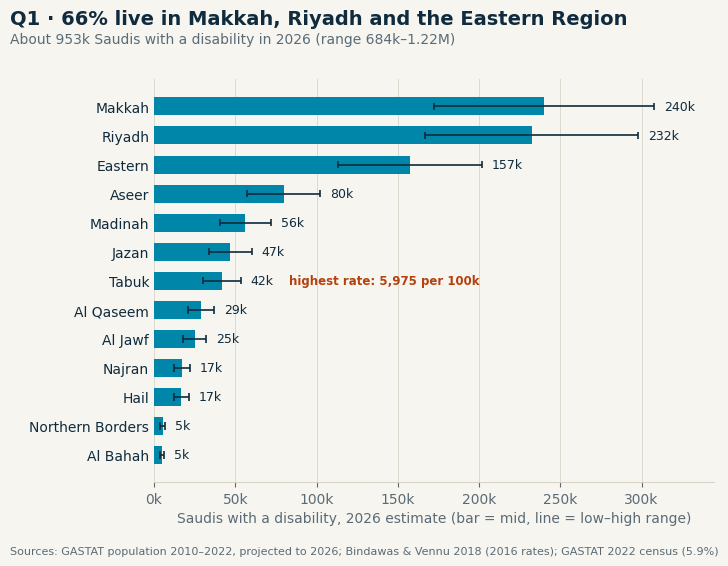

Saved outputs/figures/q1_demand_by_region.png


In [17]:
# 3.1a Q1 chart: Saudis with a disability in 2026 per region, with the low-high range

d = q1.sort_values('pwd_2026_mid')
y = np.arange(len(d))
fig, ax = plt.subplots(figsize=(8, 5.6))
ax.barh(y, d['pwd_2026_mid'], height=0.62, color=TEAL, zorder=2)
ax.hlines(y, d['pwd_2026_low'], d['pwd_2026_high'], color=INK, lw=1.2, zorder=3)
for yy, lo, hi, mid in zip(y, d['pwd_2026_low'], d['pwd_2026_high'], d['pwd_2026_mid']):
    ax.vlines([lo, hi], yy - 0.13, yy + 0.13, color=INK, lw=1.2, zorder=3)
    ax.text(hi + 6000, yy, f'{mid/1000:,.0f}k', va='center', fontsize=9)
tabuk = d.set_index('region').loc['Tabuk']
ax.text(tabuk['pwd_2026_high'] + 30000, list(d['region']).index('Tabuk'),
        f"highest rate: {tabuk['pwd_per_100k_mid']:,.0f} per 100k", va='center', fontsize=8.5, color=ORANGE, fontweight='semibold')
ax.set_yticks(y, [nm(r) for r in d['region']])
ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda v, _: f'{v/1000:,.0f}k'))
ax.set_xlim(0, d['pwd_2026_high'].max() * 1.12)
ax.set_xlabel('Saudis with a disability, 2026 estimate (bar = mid, line = low–high range)')
ax.grid(axis='x', color=LINE, lw=0.6); ax.set_axisbelow(True)
for s in ['top', 'right', 'left']: ax.spines[s].set_visible(False)
ax.tick_params(axis='y', length=0)
fig.subplots_adjust(top=0.86, bottom=0.14, left=0.2)
top3 = d.nlargest(3, 'pwd_2026_mid')['share_of_national_pct'].sum()
finish(fig, f'Q1 · {top3:.0f}% live in Makkah, Riyadh and the Eastern Region',
       f"About {d['pwd_2026_mid'].sum()/1000:,.0f}k Saudis with a disability in 2026 (range {d['pwd_2026_low'].sum()/1000:,.0f}k–{d['pwd_2026_high'].sum()/1e6:.2f}M)",
       'Sources: GASTAT population 2010–2022, projected to 2026; Bindawas & Vennu 2018 (2016 rates); GASTAT 2022 census (5.9%)',
       'q1_demand_by_region.png')

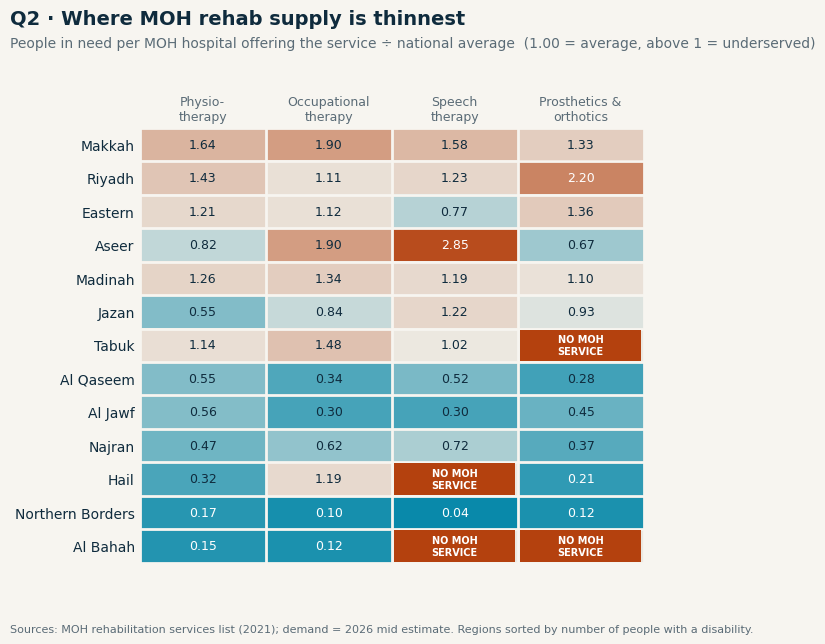

Saved outputs/figures/q2_supply_gap_heatmap.png


In [18]:
# 3.1b Q2 chart: gap index per region and service, with "no MOH service" cells highlighted

services = ['physiotherapy', 'occupational_therapy', 'speech_therapy', 'prosthetics_orthotics']
labels   = ['Physio-\ntherapy', 'Occupational\ntherapy', 'Speech\ntherapy', 'Prosthetics &\northotics']
g = q2.pivot(index='region', columns='service', values='gap_index').loc[order, services]
fig, ax = plt.subplots(figsize=(7.2, 6.4))
ax.imshow(g.fillna(1).values, cmap=div_cmap, norm=TwoSlopeNorm(vmin=0, vcenter=1, vmax=3), aspect='auto')
for i in range(g.shape[0]):
    for j in range(g.shape[1]):
        v = g.iat[i, j]
        if np.isnan(v):
            ax.add_patch(plt.Rectangle((j - .48, i - .47), .96, .94, color=ORANGE, lw=0, zorder=2))
            ax.text(j, i, 'NO MOH\nSERVICE', ha='center', va='center', fontsize=7, color='white', fontweight='semibold', zorder=3)
        else:
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                    color='white' if (v >= 2.2 or v <= 0.25) else INK, zorder=3)
ax.set_xticks(range(4), labels, fontsize=9); ax.xaxis.tick_top()
ax.set_yticks(range(len(order)), [nm(r) for r in order])
ax.set_xticks(np.arange(-.5, 4, 1), minor=True); ax.set_yticks(np.arange(-.5, len(order), 1), minor=True)
ax.grid(which='minor', color=PAPER, lw=2); ax.tick_params(which='both', length=0)
for s in ax.spines.values(): s.set_visible(False)
fig.subplots_adjust(top=0.80, bottom=0.12, left=0.2)
finish(fig, 'Q2 · Where MOH rehab supply is thinnest',
       'People in need per MOH hospital offering the service ÷ national average  (1.00 = average, above 1 = underserved)',
       'Sources: MOH rehabilitation services list (2021); demand = 2026 mid estimate. Regions sorted by number of people with a disability.',
       'q2_supply_gap_heatmap.png')

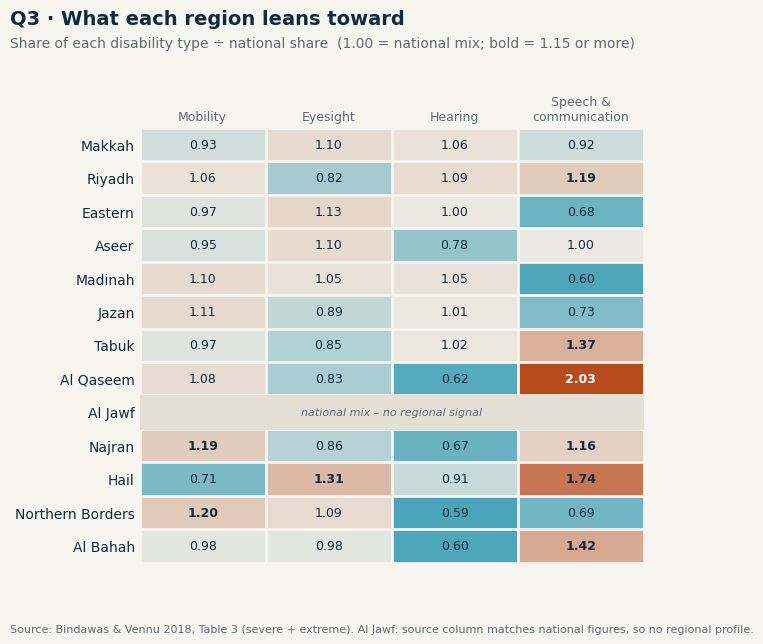

Saved outputs/figures/q3_type_mix_heatmap.png


In [19]:
# 3.1c Q3 chart: each region's disability type mix compared with the national mix; Al Jawf shown as no regional signal

types = ['Mobility', 'Eyesight', 'Hearing', 'Speech & communication']
h = q3.pivot(index='region', columns='disability_type', values='index').loc[order, types]
fig, ax = plt.subplots(figsize=(7.2, 6.4))
ax.imshow(h.values, cmap=div_cmap, norm=TwoSlopeNorm(vmin=0.4, vcenter=1, vmax=2.1), aspect='auto')
for i, region in enumerate(order):
    if region == 'Al Jawf':
        ax.add_patch(plt.Rectangle((-.5, i - .5), 4, 1, color='#E4E0D6', zorder=2))
        ax.text(1.5, i, 'national mix – no regional signal', ha='center', va='center',
                fontsize=8, color=MUTED, style='italic', zorder=3)
        continue
    for j in range(4):
        v = h.iat[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                fontweight='semibold' if v >= 1.15 else 'normal', color='white' if v >= 1.75 else INK, zorder=3)
ax.set_xticks(range(4), ['Mobility', 'Eyesight', 'Hearing', 'Speech &\ncommunication'], fontsize=9); ax.xaxis.tick_top()
ax.set_yticks(range(len(order)), [nm(r) for r in order])
ax.set_xticks(np.arange(-.5, 4, 1), minor=True); ax.set_yticks(np.arange(-.5, len(order), 1), minor=True)
ax.grid(which='minor', color=PAPER, lw=2); ax.tick_params(which='both', length=0)
for s in ax.spines.values(): s.set_visible(False)
fig.subplots_adjust(top=0.80, bottom=0.12, left=0.2)
finish(fig, 'Q3 · What each region leans toward',
       'Share of each disability type ÷ national share  (1.00 = national mix; bold = 1.15 or more)',
       'Source: Bindawas & Vennu 2018, Table 3 (severe + extreme). Al Jawf: source column matches national figures, so no regional profile.',
       'q3_type_mix_heatmap.png')

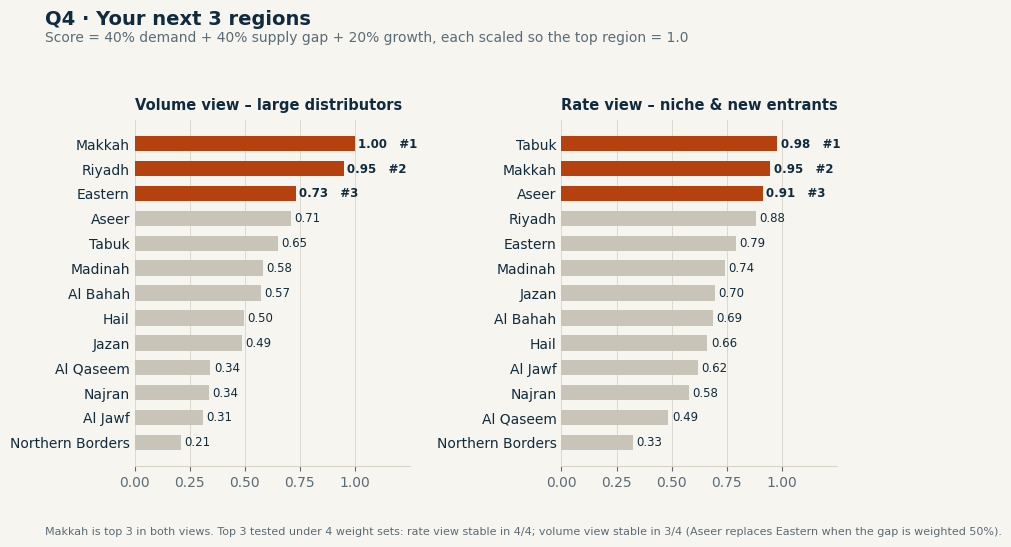

Saved outputs/figures/q4_scorecard.png


In [20]:
# 3.1d Q4 chart: both scorecard views side by side, with each view's top 3 highlighted

fig, axes = plt.subplots(1, 2, figsize=(9, 5.4))
for ax, col, rank_col, title in [(axes[0], 'score_volume', 'rank_volume', 'Volume view – large distributors'),
                                 (axes[1], 'score_rate',   'rank_rate',   'Rate view – niche & new entrants')]:
    d = sc.reset_index().sort_values(col)
    yy = np.arange(len(d))
    ax.barh(yy, d[col], height=0.62, color=[ORANGE if r <= 3 else GREY for r in d[rank_col]], zorder=2)
    for y_, v, r in zip(yy, d[col], d[rank_col]):
        ax.text(v + 0.015, y_, f'{v:.2f}' + (f'   #{r}' if r <= 3 else ''), va='center', fontsize=8.5,
                fontweight='semibold' if r <= 3 else 'normal')
    ax.set_yticks(yy, [nm(r) for r in d['region']])
    ax.set_xlim(0, 1.25); ax.set_xticks([0, .25, .5, .75, 1])
    ax.set_title(title, loc='left', fontsize=10.5, fontweight='semibold', pad=8)
    ax.grid(axis='x', color=LINE, lw=0.6); ax.set_axisbelow(True)
    for s in ['top', 'right', 'left']: ax.spines[s].set_visible(False)
    ax.tick_params(axis='y', length=0)
fig.subplots_adjust(top=0.78, bottom=0.14, left=0.12, wspace=0.55)
finish(fig, 'Q4 · Your next 3 regions',
       'Score = 40% demand + 40% supply gap + 20% growth, each scaled so the top region = 1.0',
       'Makkah is top 3 in both views. Top 3 tested under 4 weight sets: rate view stable in 4/4; volume view stable in 3/4 (Aseer replaces Eastern when the gap is weighted 50%).',
       'q4_scorecard.png')